# 🔍 E-Commerce Fraud Detection — Exploratory Data Analysis (EDA)

---

## 🎯 এই Dataset দিয়ে কী করতে চাই?

এটি একটি **E-Commerce Fraud Detection** dataset। প্রতিটি row মানে একটি online transaction।  
`is_fraud` column বলছে — সেই transaction টি fraud ছিল কিনা (1 = fraud, 0 = legitimate)।

**মূল উদ্দেশ্য:** কোন transaction গুলো suspicious, সেটা আগে থেকেই চেনার pattern বের করা।

---

## ✅ এই EDA থেকে কী Achieve করব?

| লক্ষ্য | কারণ |
|---|---|
| Dataset-এর shape ও data types বোঝা | কোন columns আছে, কোনটা কী ধরনের |
| Missing values খোঁজা | Data quality চেক করা |
| Fraud কত % — class imbalance দেখা | ML model কতটা biased হতে পারে |
| Numerical features-এর distribution দেখা | Normal নাকি Skewed? |
| Categorical features-এ fraud rate বোঝা | কোন দেশ/channel-এ fraud বেশি? |
| Correlation বোঝা | কোন features fraud-এর সাথে সবচেয়ে related? |
| Outlier detect করা | Unusually high amount = fraud signal? |

---

## 🧠 তুমি যা শিখেছ, সেই আলোকে চিন্তার উপায়

| আগে যা শিখেছ | এখানে কীভাবে লাগবে |
|---|---|
| **Class Imbalance** | Fraud মাত্র ~2.2% — এটা বড় সমস্যা, model শুধু 0 predict করলেই 97.8% accurate হয়! |
| **Feature Scaling** | `amount`, `shipping_distance_km`, `account_age_days` — range অনেক আলাদা, scale করতে হবে |
| **Encoding** | `country`, `channel`, `merchant_category` — text data, encode করতে হবে |
| **Correlation** | কোন numerical feature fraud-এর সাথে বেশি correlated সেটা বুঝতে হবে |
| **Outlier Detection** | IQR দিয়ে unusually high transaction amount detect করব |

---

## 🗺️ EDA-এর Approach

```
Step 1 → Dataset Overview (shape, dtypes, missing values)
Step 2 → Descriptive Statistics
Step 3 → Target Variable Analysis (is_fraud)
Step 4 → Numerical Feature Analysis
Step 5 → Categorical Feature Analysis
Step 6 → Correlation Analysis
Step 7 → Outlier Detection
Step 8 → Feature vs Fraud Analysis
Step 9 → Key Insights & Next Steps
```

---

## Step 1 — Libraries Import ও Dataset Load

In [3]:
# Now we import all the libraries we need for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Here we've set a clean visual style for all charts
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f9f9f9'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['font.size'] = 11

print("All libraries loaded successfully!")

All libraries loaded successfully!


উপরের code-এ আমরা EDA-র জন্য দরকারি সব library import করেছি।
- **pandas** → data পড়া ও manipulation
- **numpy** → numerical calculation
- **matplotlib & seaborn** → chart তৈরি
- `warnings.filterwarnings('ignore')` → unnecessary warning message বন্ধ করা
- `plt.rcParams` দিয়ে সব chart-এর জন্য একটা clean, সাদা background set করা হয়েছে

In [4]:
# Now we load the dataset from the CSV file
df = pd.read_csv('Transactions-Dataset.csv')

# Here we've loaded the full dataset into a DataFrame called df
print(f"Dataset loaded! Total rows: {df.shape[0]:,}, Total columns: {df.shape[1]}")

Dataset loaded! Total rows: 299,695, Total columns: 17


CSV file load করে `df` নামের একটি **DataFrame**-এ রাখা হয়েছে।  
`df.shape` দিয়ে দেখছি মোট কতটি row ও column আছে।

---

## Step 2 — Dataset Overview

In [5]:
# Now we look at the first 5 rows to understand what data looks like
df.head()

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0


`df.head()` দিয়ে প্রথম ৫টি row দেখা হচ্ছে।  
এখান থেকে বোঝা যায় — প্রতিটি row একটি transaction, এবং কোন columns কী ধরনের data রাখে।

In [6]:
# Now we check the shape, data types, and non-null counts together
print("=" * 55)
print(f"  Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("=" * 55)
print()
print("Column Info:")
print("-" * 55)

# Here we've shown each column's data type and null count side by side
for col in df.columns:
    null_count = df[col].isnull().sum()
    null_flag = " ⚠️ HAS NULLS" if null_count > 0 else ""
    print(f"  {col:<30} {str(df[col].dtype):<10} nulls: {null_count}{null_flag}")

print()
print(f"Total Missing Values: {df.isnull().sum().sum()}")

  Dataset Shape: 299,695 rows × 17 columns

Column Info:
-------------------------------------------------------
  transaction_id                 int64      nulls: 0
  user_id                        int64      nulls: 0
  account_age_days               int64      nulls: 0
  total_transactions_user        int64      nulls: 0
  avg_amount_user                float64    nulls: 0
  amount                         float64    nulls: 0
  country                        object     nulls: 0
  bin_country                    object     nulls: 0
  channel                        object     nulls: 0
  merchant_category              object     nulls: 0
  promo_used                     int64      nulls: 0
  avs_match                      int64      nulls: 0
  cvv_result                     int64      nulls: 0
  three_ds_flag                  int64      nulls: 0
  transaction_time               object     nulls: 0
  shipping_distance_km           float64    nulls: 0
  is_fraud                       int64 

এই code block-এ প্রতিটি column-এর:
- **নাম** কী
- **data type** কী (int, float, str)
- **কতটি null/missing value** আছে

সেটা একসাথে দেখানো হয়েছে।  
যদি কোথাও ⚠️ দেখা যায়, সেটা missing value-র সংকেত। এই dataset-এ **কোনো missing value নেই** — এটা ভালো খবর!

In [7]:
# Now we understand what each column means
column_descriptions = {
    'transaction_id':           'Unique ID for each transaction',
    'user_id':                  'Unique ID for each user',
    'account_age_days':         'How many days old is the user account',
    'total_transactions_user':  'Total number of past transactions by this user',
    'avg_amount_user':          'Average transaction amount for this user historically',
    'amount':                   'Amount of THIS transaction (in USD)',
    'country':                  'Country where the transaction happened',
    'bin_country':              'Country linked to the card BIN (Bank Identification Number)',
    'channel':                  'How the transaction was done (web or app)',
    'merchant_category':        'Type of store / merchant',
    'promo_used':               'Was a promo/coupon used? (1=Yes, 0=No)',
    'avs_match':                'Did billing address match card records? (1=Yes, 0=No)',
    'cvv_result':               'Was the CVV code correct? (1=Yes, 0=No)',
    'three_ds_flag':            'Was 3D Secure authentication used? (1=Yes, 0=No)',
    'transaction_time':         'Date and time of the transaction',
    'shipping_distance_km':     'Distance between billing and shipping address (km)',
    'is_fraud':                 '🎯 TARGET: Was this transaction fraud? (1=Yes, 0=No)'
}

# Here we've printed a clean description table for all columns
print("Column Descriptions:")
print("-" * 75)
for col, desc in column_descriptions.items():
    print(f"  {col:<30} → {desc}")

Column Descriptions:
---------------------------------------------------------------------------
  transaction_id                 → Unique ID for each transaction
  user_id                        → Unique ID for each user
  account_age_days               → How many days old is the user account
  total_transactions_user        → Total number of past transactions by this user
  avg_amount_user                → Average transaction amount for this user historically
  amount                         → Amount of THIS transaction (in USD)
  country                        → Country where the transaction happened
  bin_country                    → Country linked to the card BIN (Bank Identification Number)
  channel                        → How the transaction was done (web or app)
  merchant_category              → Type of store / merchant
  promo_used                     → Was a promo/coupon used? (1=Yes, 0=No)
  avs_match                      → Did billing address match card records? (1=Yes, 

এই block-এ প্রতিটি column কী অর্থ বহন করে তা manually লেখা হয়েছে।  
EDA শুরু করার আগে **domain knowledge** বোঝাটা খুব জরুরি — না হলে কোন column গুরুত্বপূর্ণ সেটা বোঝা যাবে না।

বিশেষভাবে লক্ষ্য করো:
- `avs_match`, `cvv_result`, `three_ds_flag` — এগুলো **security check** এর result।  
  যদি এগুলো fail করে (0), সেটা fraud-এর একটি সংকেত হতে পারে।
- `shipping_distance_km` — billing আর shipping address অনেক দূরে হলে সেটা suspicious।

---

## Step 3 — Descriptive Statistics

In [24]:
# Now we get descriptive statistics for all numerical columns
numerical_cols = ['account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'shipping_distance_km']

# Here we've shown mean, std, min, max, quartiles for each numerical column
desc = df[numerical_cols].describe().round(2)
# desc = df[numerical_cols].describe().round(2).T
desc

,account_age_days,total_transactions_user,avg_amount_user,amount,shipping_distance_km
count,299695.00,299695.00,299695.00,299695.00,299695.00
mean,973.40,50.67,148.14,177.17,357.05
std,525.24,5.98,200.36,306.93,427.67
min,1.00,40.00,3.52,1.00,0.00
25%,516.00,46.00,46.19,42.10,136.60
50%,975.00,51.00,90.13,89.99,273.02
75%,1425.00,56.00,173.45,191.11,409.18
max,1890.00,60.00,4565.29,16994.74,3748.56


`describe()` function প্রতিটি numerical column-এর জন্য দেয়:
- **count** → কতটি valid value আছে
- **mean** → গড়
- **std** → Standard Deviation (মান কতটা ছড়িয়ে আছে)
- **min / max** → সর্বনিম্ন ও সর্বোচ্চ মান
- **25%, 50%, 75%** → Quartile (Q1, Median, Q3)

**লক্ষ্য করো:**
- `amount` এর mean ≈ $177, কিন্তু max ≈ $16,994 → বড় outlier আছে!
- `shipping_distance_km` এর max ≈ 3,748 km → কিছু transaction-এ বিশাল দূরত্ব!

---

## Step 4 — Target Variable Analysis (is_fraud)

In [9]:
# Now we analyze how balanced our target variable is
fraud_counts = df['is_fraud'].value_counts()
fraud_pct = df['is_fraud'].value_counts(normalize=True) * 100

print("Target Variable Distribution:")
print("-" * 40)
print(f"  Legitimate (0): {fraud_counts[0]:>8,}  ({fraud_pct[0]:.2f}%)")
print(f"  Fraud      (1): {fraud_counts[1]:>8,}  ({fraud_pct[1]:.2f}%)")
print(f"  Total         : {len(df):>8,}")
print()

# Here we've calculated the imbalance ratio
ratio = fraud_counts[0] / fraud_counts[1]
print(f"  Imbalance Ratio: {ratio:.1f}:1  (for every 1 fraud, there are {ratio:.0f} legitimate transactions)")

Target Variable Distribution:
----------------------------------------
  Legitimate (0):  293,083  (97.79%)
  Fraud      (1):    6,612  (2.21%)
  Total         :  299,695

  Imbalance Ratio: 44.3:1  (for every 1 fraud, there are 44 legitimate transactions)


এই block-এ দেখা যাচ্ছে:
- Fraud transaction মাত্র **~2.2%** — বাকি 97.8% legitimate
- এটি একটি **severely imbalanced dataset**

⚠️ **এটা কেন সমস্যা?**  
একটি naive model যদি সব transaction-কে "0 (not fraud)" predict করে, সে তবুও 97.8% accurate হবে!  
কিন্তু সে কোনো fraud-ই ধরতে পারবে না।  
তাই পরে ML model বানানোর সময় **SMOTE** বা **class_weight='balanced'** ব্যবহার করতে হবে।

**SMOTE (Synthetic Minority Over-sampling Technique)** is a machine learning algorithm used to address imbalanced datasets by generating synthetic samples for the minority class.

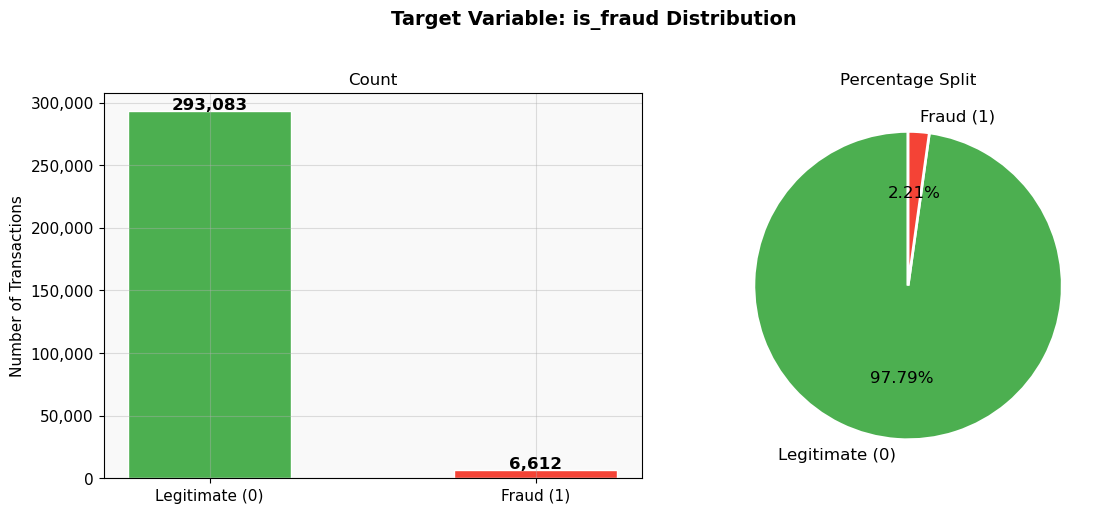

In [10]:
# Now we visualize the class imbalance with a clear chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Target Variable: is_fraud Distribution', fontsize=14, fontweight='bold', y=1.02)

colors = ['#4CAF50', '#F44336']
labels = ['Legitimate (0)', 'Fraud (1)']

# Here we've drawn a bar chart on the left
bars = axes[0].bar(labels, fraud_counts.values, color=colors, edgecolor='white', width=0.5)
for bar, count in zip(bars, fraud_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{count:,}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Count', fontsize=12)
axes[0].set_ylabel('Number of Transactions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Here we've drawn a pie chart on the right to show percentages
axes[1].pie(fraud_counts.values, labels=labels, colors=colors,
            autopct='%1.2f%%', startangle=90,
            textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Percentage Split', fontsize=12)

plt.tight_layout()
plt.savefig('plot_01_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

এই chart-এ স্পষ্ট দেখা যাচ্ছে dataset কতটা imbalanced।  
- বাম দিকের **bar chart** দেখাচ্ছে actual count
- ডান দিকের **pie chart** দেখাচ্ছে percentage split

সবুজ অংশ (legitimate) প্রায় পুরো pie জুড়ে আছে — fraud (লাল) মাত্র একটি ছোট্ট অংশ।


# Target Variable: `is_fraud` Distribution — পড়ার গাইড

## 📊 Chart কী দেখাচ্ছে?

এটি আগের Heart Disease dataset-এর target distribution chart-এর মতোই — কিন্তু এবার dataset হলো **fraud detection**। Target variable: `is_fraud` (0 = Legitimate, 1 = Fraud)।

## 🔍 Observation

### Left — Bar Chart (Count)

| Class | Count |
|---|---|
| Legitimate (0) | **293,083** |
| Fraud (1) | **6,612** |

- Fraud bar এতটাই ছোট যে প্রায় **দেখাই যাচ্ছে না** — এটাই সমস্যার মূল চিহ্ন।

### Right — Pie Chart (Proportion)

| Class | Percentage |
|---|---|
| Legitimate (0) | **97.79%** |
| Fraud (1) | **2.21%** |

- Pie chart-এ লাল অংশ (Fraud) একটি সরু **sliver** — বাকি সবটা সবুজ।

## ⚖️ Balance Check

```
ratio = minority / majority
      = 6,612 / 293,083
      ≈ 0.023
```

| Threshold | Result |
|---|---|
| > 0.8 → Balanced | ❌ |
| 0.5–0.8 → Slightly Imbalanced | ❌ |
| < 0.5 → **Imbalanced** | ✅ **এটি** |

এই dataset **severely imbalanced** — ratio মাত্র **0.023**।


## ⚠️ এই Imbalance কেন বিপজ্জনক?

ধরো model কিছু না শিখে সব transaction-কে "Legitimate" বলে দিল:

```
Accuracy = 293,083 / 299,695 = 97.79% ✅ (কিন্তু useless!)
```

Model 97.79% accurate হবে — কিন্তু **একটি fraud-ও ধরতে পারবে না।** এই ঘটনাকে বলে **Accuracy Paradox**।

> তাই এই ধরনের dataset-এ **accuracy** দেখা ঠিক নয় — দেখতে হবে **Precision, Recall, F1-score, ROC-AUC**।

## ✅ সমাধান কী?

| Technique | কী করে |
|---|---|
| **SMOTE** (Oversampling) | Fraud class-এর synthetic data তৈরি করে |
| **Undersampling** | Legitimate class থেকে কিছু বাদ দেয় |
| **`class_weight='balanced'`** | Model-কে fraud-এর দিকে বেশি মনোযোগ দিতে বলে |
| **Threshold tuning** | Default 0.5 threshold পরিবর্তন করে |

> **Interview tip:** Fraud detection, disease diagnosis, spam filtering — এই সব problem-এ **severe class imbalance** স্বাভাবিক। Interviewer জিজ্ঞেস করলে বলবে — "Accuracy দেখব না, **Recall** দেখব কারণ fraud miss করা (False Negative) সবচেয়ে বেশি ক্ষতিকর।" এটাই **domain-aware evaluation** এর উদাহরণ।

---

## Step 5 — Numerical Feature Analysis

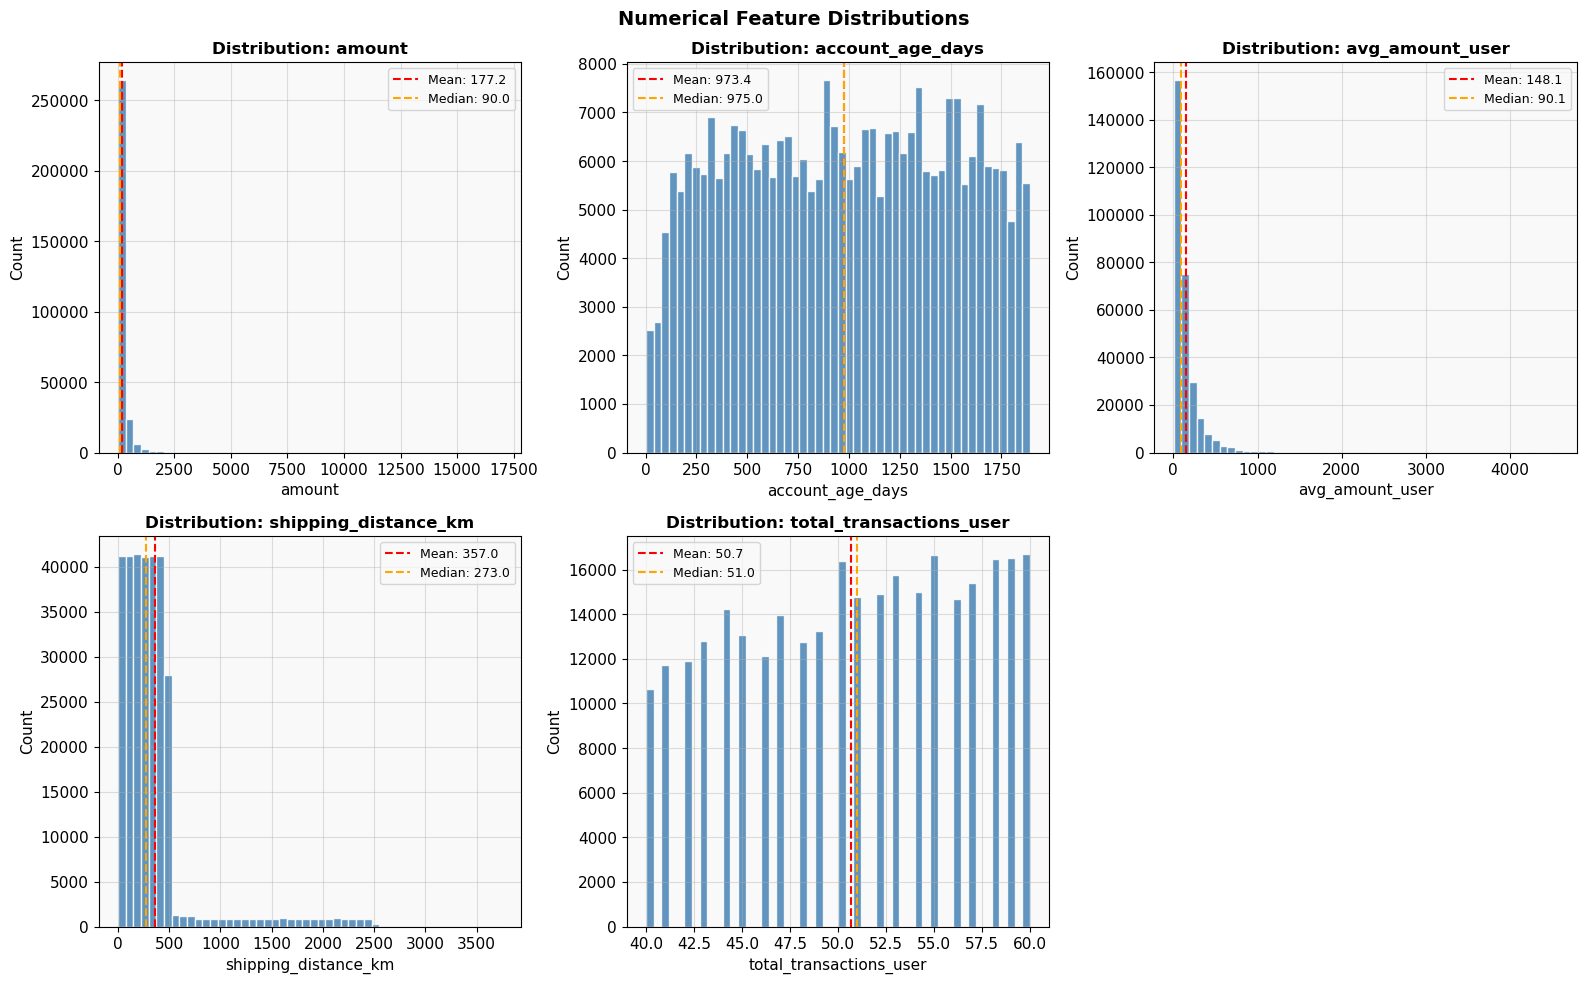

In [11]:
# Now we plot distribution histograms for all numerical features
numerical_cols = ['amount', 'account_age_days', 'avg_amount_user',
                  'shipping_distance_km', 'total_transactions_user']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Here we've drawn a separate histogram for each numerical feature
for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

    # Here we've added mean and median lines to each chart
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[i].axvline(mean_val,   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='orange', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.1f}')
    axes[i].legend(fontsize=9)

axes[-1].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_02_numerical_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

প্রতিটি numerical feature-এর জন্য একটি করে **histogram** তৈরি করা হয়েছে।
- **লাল dashed line** = Mean (গড়)
- **কমলা dashed line** = Median (মধ্যমান)

যদি Mean > Median হয়, distribution **right-skewed** (ডানে লম্বা লেজ) — মানে কিছু অনেক বড় মান আছে।  
এখানে `amount` এবং `shipping_distance_km` স্পষ্টভাবে right-skewed — কিছু transaction-এ amount বা distance অনেক বেশি।

# Numerical Feature Distributions — পড়ার গাইড

## 📐 এই Chart-এর বিশেষত্ব কী?

প্রতিটি histogram-এ দুটো **dashed line** যোগ করা হয়েছে:
- 🔴 **Red line** = Mean (গড়)
- 🟡 **Orange line** = Median (মধ্যমান)

> এই দুটো line-এর **দূরত্ব** দেখেই বোঝা যায় distribution কতটা **skewed** এবং **outlier** আছে কিনা।

```
Mean ≈ Median  →  Symmetric (normal)
Mean > Median  →  Right-skewed (ডানে লেজ, outlier উপরে)
Mean < Median  →  Left-skewed (বামে লেজ)
```

## 🔍 Feature-by-Feature Observation

### 1. `amount` (লেনদেনের পরিমাণ) ⚠️
- Mean = **177.2**, Median = **90.0** → Mean প্রায় দ্বিগুণ
- প্রায় সব transaction 0–500 range-এ, কিন্তু কিছু 17,500 পর্যন্ত আছে
- **Severely right-skewed** — বড় outlier আছে
- 🔴 Log transformation দরকার হবে

### 2. `account_age_days` (অ্যাকাউন্টের বয়স) ✅
- Mean = **973.4**, Median = **975.0** → প্রায় সমান
- Bar গুলো মোটামুটি সমান উচ্চতায় — **uniform/flat distribution**
- কোনো extreme skew নেই, কোনো suspicious spike নেই
- এই feature টি **clean এবং stable**

### 3. `avg_amount_user` (ব্যবহারকারীর গড় লেনদেন) ⚠️
- Mean = **148.1**, Median = **90.1** → Mean অনেক বেশি
- `amount`-এর মতোই — বামে বিশাল spike, ডানে লম্বা tail
- **Severely right-skewed**, outlier আছে
- 🔴 `amount`-এর সাথে highly correlated হতে পারে — **multicollinearity চেক** করতে হবে

### 4. `shipping_distance_km` (শিপিং দূরত্ব) ⚠️
- Mean = **357.0**, Median = **273.0** → Mean বেশি
- 0–500 km range-এ সব data জমে আছে, তারপর হঠাৎ drop
- **Right-skewed with long tail** — কিছু transaction অনেক দূরে ship হয়েছে
- Fraud-এ দূরবর্তী shipping বেশি হতে পারে — **potentially useful feature**

### 5. `total_transactions_user` (মোট লেনদেন সংখ্যা) ✅
- Mean = **50.7**, Median = **51.0** → প্রায় সমান
- Bar গুলো 40–60 range-এ সমানভাবে ছড়ানো — **uniform distribution**
- কোনো skew নেই, outlier নেই
- এই feature টিও **clean**

## 📋 Skewness Summary

| Feature | Mean vs Median | Shape | করণীয় |
|---|---|---|---|
| `amount` | Mean >> Median | Severe right-skew | **Log transform** |
| `account_age_days` | প্রায় সমান | Uniform | কিছু করতে হবে না |
| `avg_amount_user` | Mean >> Median | Severe right-skew | **Log transform** |
| `shipping_distance_km` | Mean > Median | Right-skew | Log বা **RobustScaler** |
| `total_transactions_user` | প্রায় সমান | Uniform | কিছু করতে হবে না |

## ⚡ Mean vs Median দূরত্ব দিয়ে কী বোঝা যায়?

```
amount:
  Mean   = 177.2  ←── outlier টেনে উপরে নিয়ে গেছে
  Median =  90.0  ←── outlier-এর প্রভাব নেই

পার্থক্য = 87.2 → অনেক বড় → severe skew
```

> **Interview tip:** Right-skewed feature-এ **StandardScaler** কাজ করে না ভালো — কারণ outlier mean ও std দুটোই distort করে। এই ক্ষেত্রে `np.log1p()` দিয়ে আগে transform করো, তারপর scale করো। অথবা সরাসরি **RobustScaler** ব্যবহার করো যেটা median ও IQR ব্যবহার করে — outlier-এর প্রভাব কম।

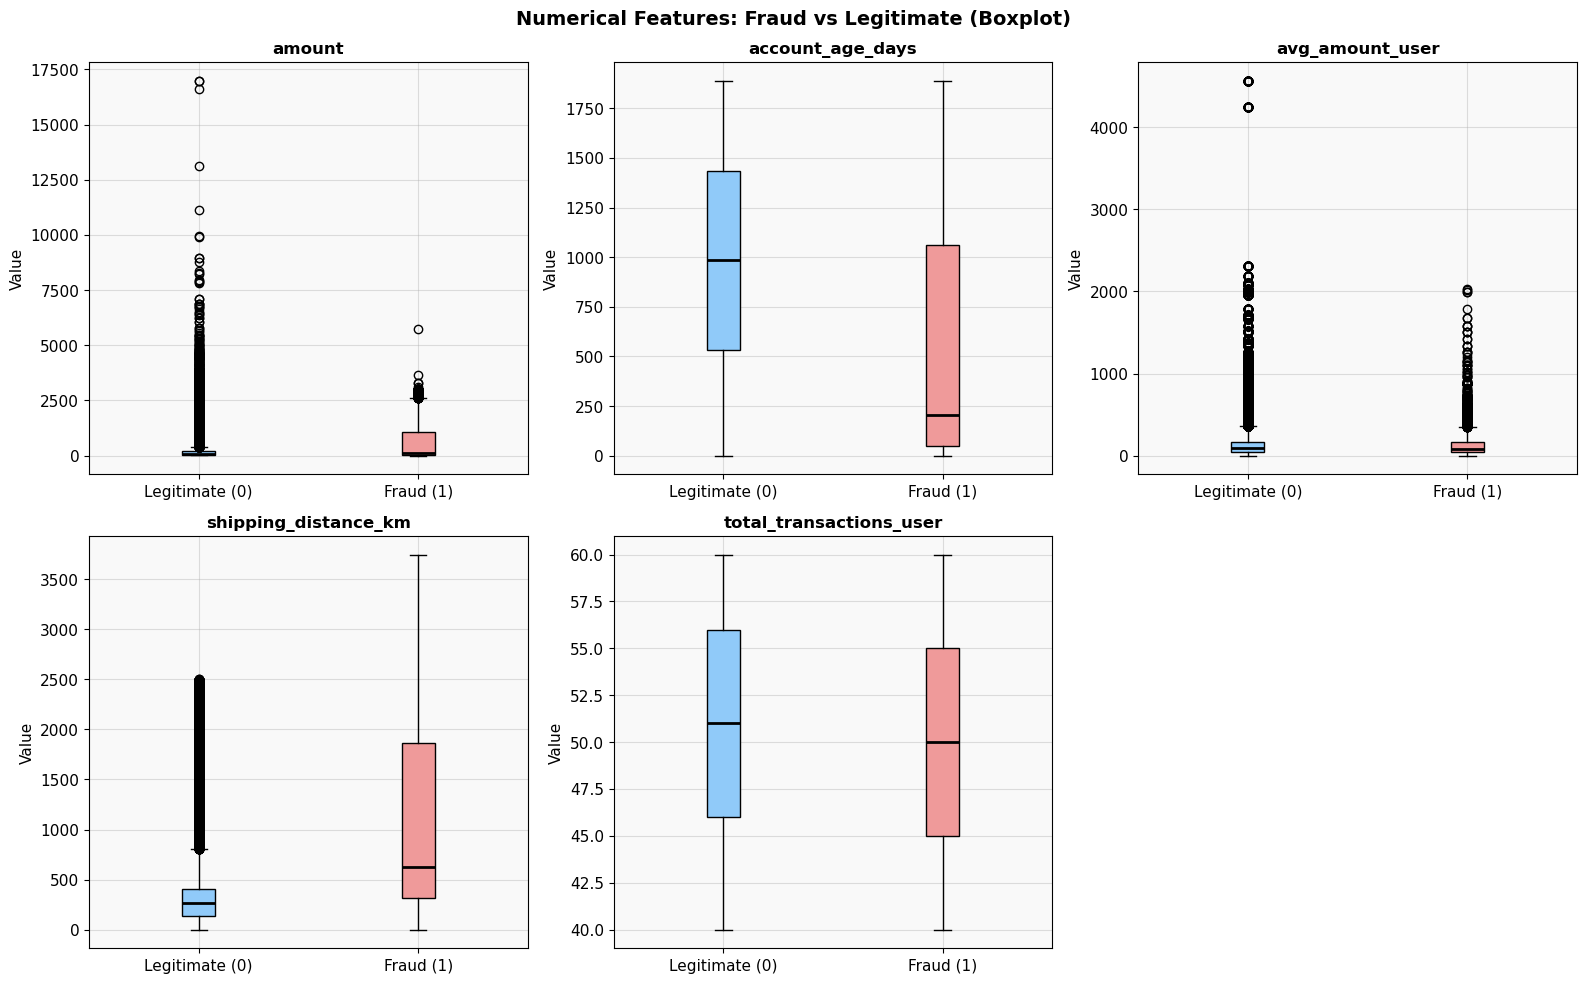

In [12]:
# Now we compare numerical features between fraud and legitimate transactions using boxplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Here we've drawn a boxplot for each feature, split by fraud vs legitimate
for i, col in enumerate(numerical_cols):
    fraud_data = df[df['is_fraud'] == 1][col]
    legit_data = df[df['is_fraud'] == 0][col]

    bp = axes[i].boxplot([legit_data, fraud_data],
                          labels=['Legitimate (0)', 'Fraud (1)'],
                          patch_artist=True,
                          medianprops=dict(color='black', linewidth=2))

    # Here we've colored the boxes differently for each class
    bp['boxes'][0].set_facecolor('#90CAF9')
    bp['boxes'][1].set_facecolor('#EF9A9A')

    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')

axes[-1].set_visible(False)

plt.suptitle('Numerical Features: Fraud vs Legitimate (Boxplot)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_03_boxplot_fraud_vs_legit.png', dpi=120, bbox_inches='tight')
plt.show()

**Boxplot** দুটো class (Fraud vs Legitimate)-এর numerical feature-গুলো তুলনা করে দেখাচ্ছে।
- **নীল box** = Legitimate transactions
- **লাল box** = Fraud transactions

যদি দুটো box-এর মাঝে পরিষ্কার পার্থক্য থাকে, মানে সেই feature ML model-এ fraud detect করতে কাজে আসবে।

⚠️ **Interview-এ বলতে পারো:** যেসব feature-এ fraud ও legitimate-এর box clearly আলাদা, সেগুলো **discriminative features** — ML model-এর জন্য সবচেয়ে valuable।

---

## Step 6 — Categorical Feature Analysis

In [13]:
# Now we calculate fraud rate for each category in every categorical column
categorical_cols = ['country', 'channel', 'merchant_category',
                    'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag']

# Here we've printed fraud rate breakdown for each categorical feature
for col in categorical_cols:
    fraud_by_cat = df.groupby(col)['is_fraud'].agg(['sum', 'count'])
    fraud_by_cat['fraud_rate_%'] = (fraud_by_cat['sum'] / fraud_by_cat['count'] * 100).round(2)
    fraud_by_cat.columns = ['fraud_count', 'total_count', 'fraud_rate_%']
    fraud_by_cat = fraud_by_cat.sort_values('fraud_rate_%', ascending=False)

    print(f"\n{'='*55}")
    print(f"  Feature: {col}")
    print(f"{'='*55}")
    print(fraud_by_cat.to_string())


  Feature: country
         fraud_count  total_count  fraud_rate_%
country                                        
TR               843        30074          2.80
RO               709        29501          2.40
PL               701        29965          2.34
ES               668        28885          2.31
US               748        32430          2.31
FR               664        30343          2.19
IT               607        28615          2.12
GB               648        30602          2.12
NL               539        30220          1.78
DE               485        29060          1.67

  Feature: channel
         fraud_count  total_count  fraud_rate_%
channel                                        
web             5426       152226          3.56
app             1186       147469          0.80

  Feature: merchant_category
                   fraud_count  total_count  fraud_rate_%
merchant_category                                        
travel                    1388        59922   

প্রতিটি categorical column-এর প্রতিটি unique value-এর জন্য দেখানো হচ্ছে:
- `fraud_count` → কতটি fraud transaction আছে সেই category-তে
- `total_count` → সেই category-তে মোট কতটি transaction
- `fraud_rate_%` → শতকরা কত ভাগ transaction fraud

উদাহরণ: যদি `avs_match = 0` (address মিলেনি) হলে fraud rate বেশি হয়, তাহলে এটা একটি শক্তিশালী fraud signal।

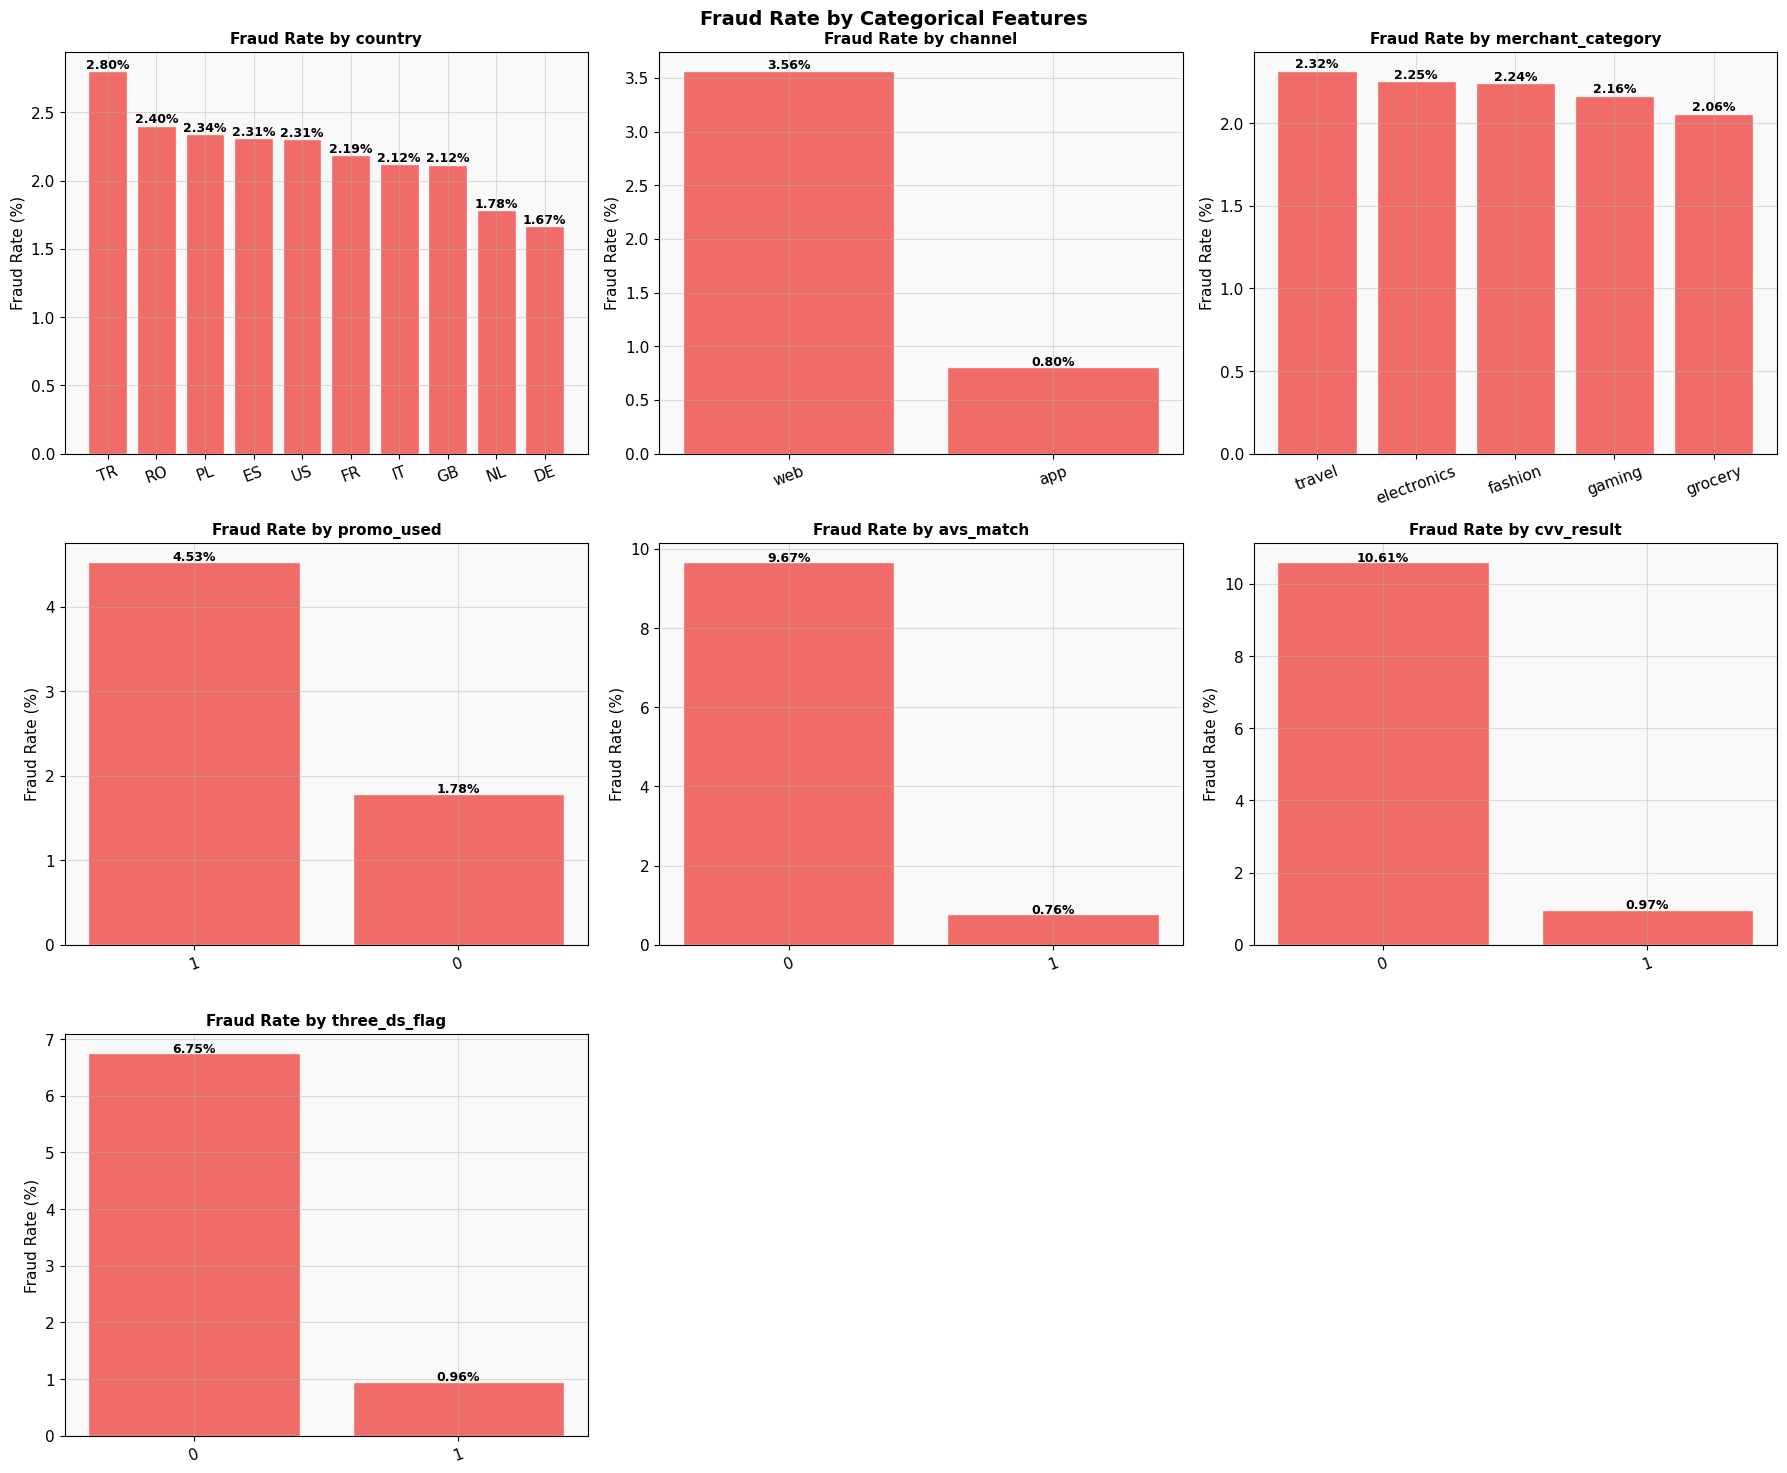

In [14]:
# Now we visualize fraud rate for all categorical features as bar charts
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# Here we've drawn a separate bar chart for each categorical feature
for i, col in enumerate(categorical_cols):
    fraud_rate = (df.groupby(col)['is_fraud'].mean() * 100).sort_values(ascending=False)

    bars = axes[i].bar(fraud_rate.index.astype(str),
                        fraud_rate.values,
                        color='#EF5350',
                        edgecolor='white',
                        alpha=0.85)

    # Here we've added the exact fraud % on top of each bar
    for bar, val in zip(bars, fraud_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f'{val:.2f}%', ha='center', fontsize=9, fontweight='bold')

    axes[i].set_title(f'Fraud Rate by {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Fraud Rate (%)')
    axes[i].tick_params(axis='x', rotation=20)

# Here we've hidden the extra empty subplots
for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Fraud Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_04_categorical_fraud_rates.png', dpi=120, bbox_inches='tight')
plt.show()

প্রতিটি categorical feature-এর জন্য bar chart দেখাচ্ছে — কোন category-তে fraud rate সবচেয়ে বেশি।

**লক্ষ্য করার মতো জিনিস:**
- `cvv_result = 0` (CVV ভুল) → fraud rate কি অনেক বেশি?
- `avs_match = 0` (address মিলেনি) → fraud rate কি বেশি?
- `three_ds_flag = 0` (3D Secure ছিল না) → fraud rate কি বেশি?

এগুলোর উত্তর chart দেখেই বোঝা যাবে।

---

## Step 7 — Correlation Analysis

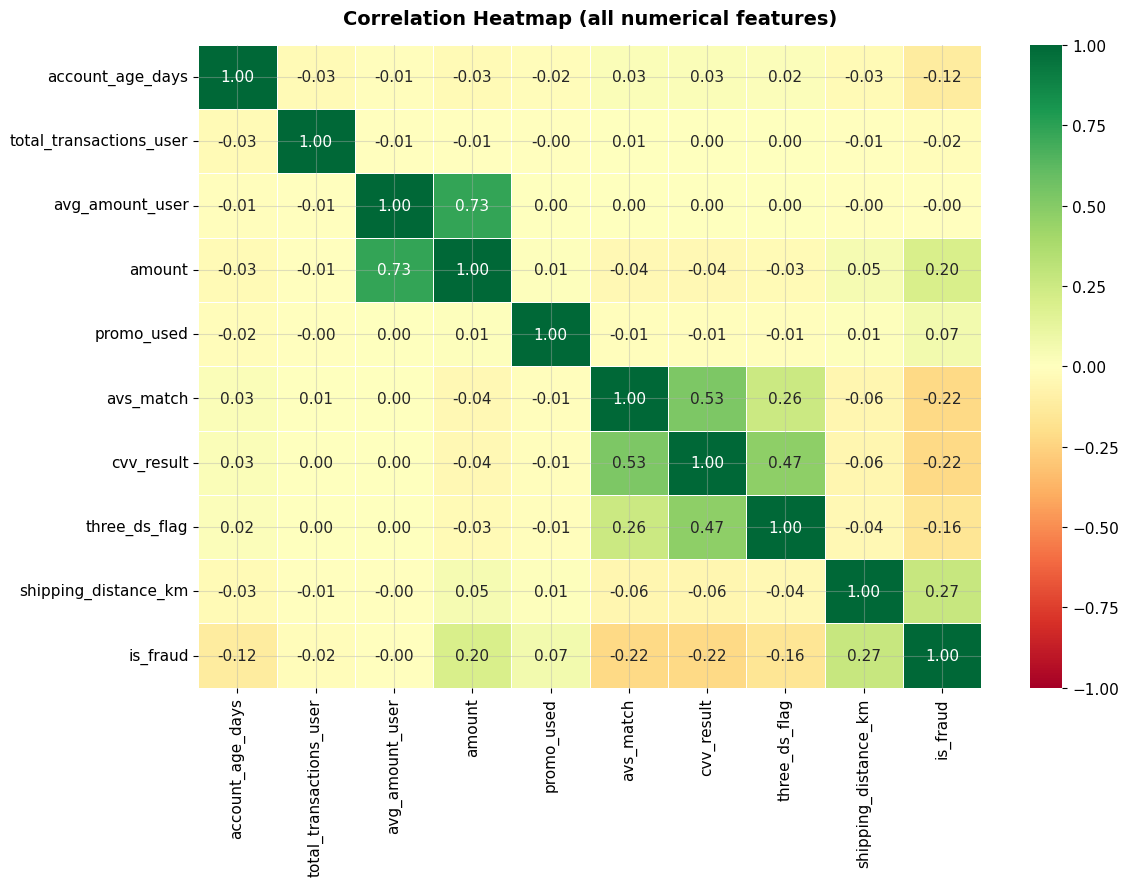

In [15]:
# Now we calculate and visualize the correlation matrix
corr_cols = ['account_age_days', 'total_transactions_user', 'avg_amount_user',
             'amount', 'promo_used', 'avs_match', 'cvv_result',
             'three_ds_flag', 'shipping_distance_km', 'is_fraud']

corr_matrix = df[corr_cols].corr().round(3)

# Here we've drawn a heatmap to show correlations between all features
fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_title('Correlation Heatmap (all numerical features)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_05_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

**Correlation Heatmap** দেখাচ্ছে কোন দুটো feature একসাথে বাড়ে বা কমে।

- **+1 (গাঢ় সবুজ)** = দুটো feature একসাথে বাড়ে (positive correlation)
- **-1 (গাঢ় লাল)** = একটা বাড়লে অন্যটা কমে (negative correlation)
- **0 (হলুদ)** = কোনো সম্পর্ক নেই

**সবচেয়ে গুরুত্বপূর্ণ row:** `is_fraud` row — এখানে দেখতে পাবে কোন features fraud-এর সাথে সবচেয়ে বেশি correlated।

In [16]:
# Now we extract and rank how much each feature correlates with is_fraud
fraud_corr = corr_matrix['is_fraud'].drop('is_fraud').sort_values(key=abs, ascending=False)

print("Feature Correlation with is_fraud (sorted by absolute value):")
print("-" * 55)

# Here we've labeled each correlation as positive, negative, or neutral
for feature, corr_val in fraud_corr.items():
    direction = "↑ positive" if corr_val > 0.01 else ("↓ negative" if corr_val < -0.01 else "  neutral")
    print(f"  {feature:<30} {corr_val:>7.4f}   {direction}")

Feature Correlation with is_fraud (sorted by absolute value):
-------------------------------------------------------
  shipping_distance_km            0.2700   ↑ positive
  avs_match                      -0.2230   ↓ negative
  cvv_result                     -0.2190   ↓ negative
  amount                          0.2020   ↑ positive
  three_ds_flag                  -0.1620   ↓ negative
  account_age_days               -0.1200   ↓ negative
  promo_used                      0.0670   ↑ positive
  total_transactions_user        -0.0170   ↓ negative
  avg_amount_user                -0.0010     neutral


এই table দেখাচ্ছে কোন feature fraud-এর সাথে কতটা এবং কোন দিকে correlated।

- **↑ positive correlation** → এই feature বাড়লে fraud হওয়ার সম্ভাবনা বাড়ে
- **↓ negative correlation** → এই feature বাড়লে fraud হওয়ার সম্ভাবনা কমে
- **neutral** → খুব কম প্রভাব

উপরে যে features গুলো আছে, সেগুলো ML model-এ বেশি কার্যকর হবে।

---

## Step 8 — Outlier Detection

In [17]:
# Now we detect outliers using the IQR method for numerical features
print("Outlier Detection using IQR Method")
print("=" * 60)
print()

outlier_summary = {}

# Here we've calculated IQR fences and counted outliers for each numerical column
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_fence) | (df[col] > upper_fence)]
    outlier_count = len(outliers)
    outlier_pct = outlier_count / len(df) * 100

    outlier_summary[col] = outlier_count

    print(f"  {col}")
    print(f"    Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"    Lower fence: {lower_fence:.2f}  |  Upper fence: {upper_fence:.2f}")
    print(f"    Outliers: {outlier_count:,} ({outlier_pct:.2f}% of all data)")
    print()

Outlier Detection using IQR Method

  amount
    Q1=42.10, Q3=191.11, IQR=149.01
    Lower fence: -181.42  |  Upper fence: 414.63
    Outliers: 26,711 (8.91% of all data)

  account_age_days
    Q1=516.00, Q3=1425.00, IQR=909.00
    Lower fence: -847.50  |  Upper fence: 2788.50
    Outliers: 0 (0.00% of all data)

  avg_amount_user
    Q1=46.19, Q3=173.45, IQR=127.26
    Lower fence: -144.70  |  Upper fence: 364.34
    Outliers: 23,890 (7.97% of all data)

  shipping_distance_km
    Q1=136.60, Q3=409.18, IQR=272.58
    Lower fence: -272.27  |  Upper fence: 818.05
    Outliers: 20,312 (6.78% of all data)

  total_transactions_user
    Q1=46.00, Q3=56.00, IQR=10.00
    Lower fence: 31.00  |  Upper fence: 71.00
    Outliers: 0 (0.00% of all data)



**IQR (Interquartile Range) Method** দিয়ে outlier detect করা হয়েছে।

**পদ্ধতি:**
1. Q1 (25th percentile) এবং Q3 (75th percentile) বের করো
2. IQR = Q3 − Q1
3. Lower fence = Q1 − 1.5 × IQR
4. Upper fence = Q3 + 1.5 × IQR
5. এই fence-এর বাইরের যেকোনো মান = **outlier**

**কেন গুরুত্বপূর্ণ?**  
Fraud transaction গুলো প্রায়ই unusually high `amount` বা `shipping_distance_km` নিয়ে আসে।  
তাই outlier মানেই fraud নয়, কিন্তু outlier-রা fraud-এর সাথে বেশি related হতে পারে।

In [18]:
# Now we check: among the outlier transactions, what fraction are fraud?
print("Are Outliers More Likely to Be Fraud?")
print("=" * 60)
print()

overall_fraud_rate = df['is_fraud'].mean() * 100

# Here we've compared fraud rate inside vs outside the outlier zone for each feature
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outlier_mask = (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)
    outlier_fraud_rate = df[outlier_mask]['is_fraud'].mean() * 100
    normal_fraud_rate  = df[~outlier_mask]['is_fraud'].mean() * 100

    signal = "🚨 STRONG SIGNAL" if outlier_fraud_rate > overall_fraud_rate * 1.5 else ""
    print(f"  {col}")
    print(f"    Fraud rate in outliers : {outlier_fraud_rate:.2f}%")
    print(f"    Fraud rate in normal   : {normal_fraud_rate:.2f}%  {signal}")
    print()

Are Outliers More Likely to Be Fraud?

  amount
    Fraud rate in outliers : 7.40%
    Fraud rate in normal   : 1.70%  🚨 STRONG SIGNAL

  account_age_days
    Fraud rate in outliers : nan%
    Fraud rate in normal   : 2.21%  

  avg_amount_user
    Fraud rate in outliers : 2.52%
    Fraud rate in normal   : 2.18%  

  shipping_distance_km
    Fraud rate in outliers : 12.81%
    Fraud rate in normal   : 1.44%  🚨 STRONG SIGNAL

  total_transactions_user
    Fraud rate in outliers : nan%
    Fraud rate in normal   : 2.21%  



এখানে compare করা হচ্ছে:
- **Outlier transactions** (যেগুলো অস্বাভাবিক range-এ আছে) → তাদের মধ্যে fraud rate কত?
- **Normal transactions** → তাদের মধ্যে fraud rate কত?

যদি কোনো feature-এ 🚨 **STRONG SIGNAL** দেখায়, মানে সেই feature-এর outlier value গুলো fraud-এর সাথে জোরালোভাবে সম্পর্কিত।  
এই ধরনের feature ML model-এর জন্য **খুবই গুরুত্বপূর্ণ**।

---

## Step 9 — Security Features Deep Dive

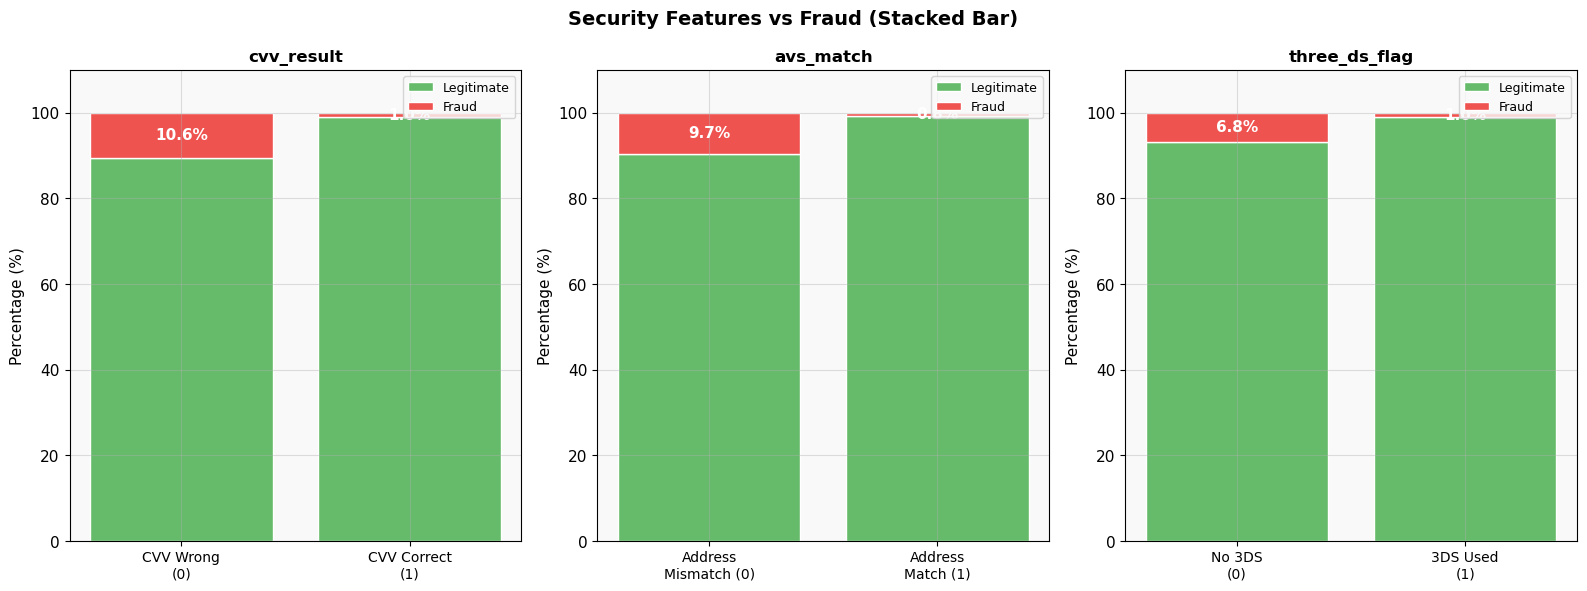

In [19]:
# Now we specifically analyze the 3 security check features vs fraud
security_features = ['cvv_result', 'avs_match', 'three_ds_flag']
labels_map = {
    'cvv_result':    {0: 'CVV Wrong\n(0)', 1: 'CVV Correct\n(1)'},
    'avs_match':     {0: 'Address\nMismatch (0)', 1: 'Address\nMatch (1)'},
    'three_ds_flag': {0: 'No 3DS\n(0)', 1: '3DS Used\n(1)'}
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Here we've drawn a stacked bar to show fraud vs legitimate split inside each category
for i, col in enumerate(security_features):
    ct = df.groupby([col, 'is_fraud']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    bar_labels = [labels_map[col][v] for v in ct_pct.index]
    x = range(len(bar_labels))

    axes[i].bar(x, ct_pct[0], label='Legitimate', color='#66BB6A', edgecolor='white')
    axes[i].bar(x, ct_pct[1], bottom=ct_pct[0], label='Fraud', color='#EF5350', edgecolor='white')

    # Here we've added fraud % labels on the red bars
    for j, (legit, fraud) in enumerate(zip(ct_pct[0], ct_pct[1])):
        axes[i].text(j, legit + fraud/2, f'{fraud:.1f}%',
                     ha='center', va='center', color='white', fontweight='bold', fontsize=11)

    axes[i].set_xticks(list(x))
    axes[i].set_xticklabels(bar_labels, fontsize=10)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(loc='upper right', fontsize=9)
    axes[i].set_ylim(0, 110)

plt.suptitle('Security Features vs Fraud (Stacked Bar)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_06_security_features.png', dpi=120, bbox_inches='tight')
plt.show()

এই chart-এ তিনটি security feature (`cvv_result`, `avs_match`, `three_ds_flag`) দেখানো হয়েছে।

প্রতিটি bar-এ **সাদা সংখ্যাটি** হলো সেই category-র fraud percentage।

**যা দেখার:**
- CVV ভুল দিলে (0) fraud বেশি হয় কিনা?
- Address না মিললে (avs_match=0) fraud বেশি কিনা?
- 3DS Authentication না থাকলে (0) fraud বেশি কিনা?

এই answers গুলো fraud detection-এর business logic বুঝতে সাহায্য করে।

---

## Step 10 — Amount Distribution: Fraud vs Legitimate

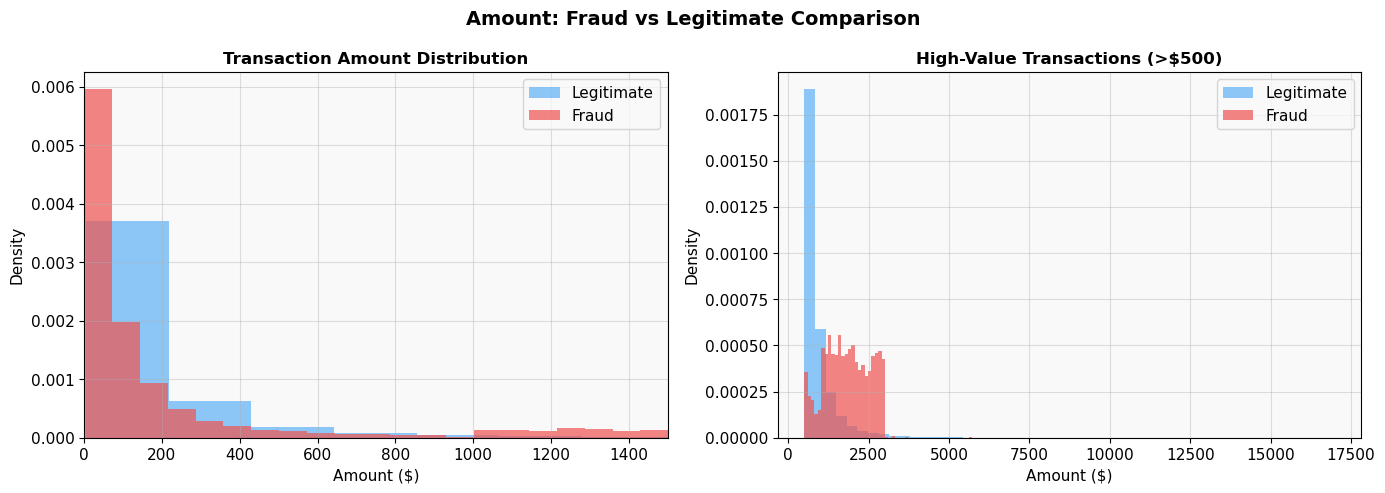

Median amount - Legitimate: $89.84
Median amount - Fraud:      $103.16


In [20]:
# Now we compare amount distribution between fraud and legitimate transactions
fraud_amounts = df[df['is_fraud'] == 1]['amount']
legit_amounts = df[df['is_fraud'] == 0]['amount']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Here we've drawn overlapping histograms to compare the two distributions
axes[0].hist(legit_amounts, bins=80, alpha=0.6, color='#42A5F5', label='Legitimate', density=True)
axes[0].hist(fraud_amounts, bins=80, alpha=0.7, color='#EF5350', label='Fraud', density=True)
axes[0].set_title('Transaction Amount Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_xlim(0, 1500)

# Here we've drawn a zoomed-in view for high-value transactions only
axes[1].hist(legit_amounts[legit_amounts > 500], bins=50, alpha=0.6, color='#42A5F5', label='Legitimate', density=True)
axes[1].hist(fraud_amounts[fraud_amounts > 500], bins=50, alpha=0.7, color='#EF5350', label='Fraud', density=True)
axes[1].set_title('High-Value Transactions (>$500)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Amount: Fraud vs Legitimate Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_07_amount_fraud_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# Here we've also printed the median amounts for both classes
print(f"Median amount - Legitimate: ${legit_amounts.median():.2f}")
print(f"Median amount - Fraud:      ${fraud_amounts.median():.2f}")

এই chart-এ fraud ও legitimate transaction-এর `amount` distribution তুলনা করা হয়েছে।

- **নীল = Legitimate**, **লাল = Fraud**
- বাম chart: সব transaction (general view)
- ডান chart: শুধু $500-এর বেশি (high-value zoom)

যদি fraud-এর distribution টা legitimate-থেকে আলাদা জায়গায় peak করে, মানে `amount` একটি গুরুত্বপূর্ণ fraud signal।

---

## Step 11 — Key Insights & Next Steps

In [21]:
# Now we print a clean final summary of all key findings
print("=" * 65)
print("           EDA FINAL SUMMARY — KEY INSIGHTS")
print("=" * 65)

# Here we've computed and printed the most important facts from the EDA
fraud_rate = df['is_fraud'].mean() * 100
total_fraud = df['is_fraud'].sum()
total_transactions = len(df)

print(f"""
DATASET FACTS:
  Total Transactions  : {total_transactions:,}
  Total Fraud Cases   : {total_fraud:,}  ({fraud_rate:.2f}%)
  Missing Values      : 0 (clean dataset)

CLASS IMBALANCE:
  Fraud is only {fraud_rate:.2f}% — severely imbalanced!
  Fix: Use SMOTE or class_weight='balanced' in ML model

TOP FRAUD-CORRELATED FEATURES:
  Run correlation analysis output above to see ranked list

SECURITY FEATURES:
  cvv_result=0   → CVV mismatch = higher fraud rate
  avs_match=0    → Address mismatch = higher fraud rate
  three_ds_flag  → Check if 3DS reduces fraud

OUTLIERS:
  amount has very high outliers (max ~$16,994)
  shipping_distance_km has very high outliers (max ~3,748 km)
  Outliers may carry fraud signal — check outlier analysis above

PREPROCESSING CHECKLIST FOR ML:
  [1] Scale numerical features (amount, distance, age)
  [2] Encode categorical features (country, channel, merchant_category)
  [3] Handle class imbalance (SMOTE / class weights)
  [4] Consider feature engineering (e.g. amount/avg_amount ratio)
  [5] Train/Test split with stratify=True (to preserve fraud ratio)
""")
print("=" * 65)

           EDA FINAL SUMMARY — KEY INSIGHTS

DATASET FACTS:
  Total Transactions  : 299,695
  Total Fraud Cases   : 6,612  (2.21%)
  Missing Values      : 0 (clean dataset)

CLASS IMBALANCE:
  Fraud is only 2.21% — severely imbalanced!
  Fix: Use SMOTE or class_weight='balanced' in ML model

TOP FRAUD-CORRELATED FEATURES:
  Run correlation analysis output above to see ranked list

SECURITY FEATURES:
  cvv_result=0   → CVV mismatch = higher fraud rate
  avs_match=0    → Address mismatch = higher fraud rate
  three_ds_flag  → Check if 3DS reduces fraud

OUTLIERS:
  amount has very high outliers (max ~$16,994)
  shipping_distance_km has very high outliers (max ~3,748 km)
  Outliers may carry fraud signal — check outlier analysis above

PREPROCESSING CHECKLIST FOR ML:
  [1] Scale numerical features (amount, distance, age)
  [2] Encode categorical features (country, channel, merchant_category)
  [3] Handle class imbalance (SMOTE / class weights)
  [4] Consider feature engineering (e.g. amou

এই final summary block-এ পুরো EDA-র সব গুরুত্বপূর্ণ তথ্য একসাথে দেখানো হয়েছে।

**পরের পদক্ষেপ (ML Model বানানোর আগে যা করতে হবে):**

| কাজ | কারণ |
|---|---|
| Numerical features → Scale করা | `amount` ও `distance`-এর range অনেক বড় |
| Categorical features → Encode করা | ML model text বোঝে না |
| Class imbalance → Fix করা | Fraud মাত্র 2.2%, model biased হয়ে যাবে |
| Feature engineering | `amount / avg_amount_user` ratio — user-এর normal spending থেকে কতটা বেশি? |
| Train/Test split → `stratify=True` | যাতে test set-এও fraud-এর ratio সঠিক থাকে |

---

> ⚠️ **Interview tip:** EDA শেষ করার পরে সবসময় বলো — "এই observations-এর উপর ভিত্তি করে আমি কোন preprocessing steps নেব এবং কেন।" এটাই একজন প্রকৃত **Data Scientist-এর চিন্তাভঙ্গি।**

---